In [30]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

print("Database created and connected successfully.")

Database created and connected successfully.


In [32]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

print("Sales table created successfully.")

Sales table created successfully.


In [33]:
sales_data = [
    ("Laptop", 5, 50000),
    ("Mobile", 10, 20000),
    ("Headphones", 15, 1500),
    ("Laptop", 3, 50000),
    ("Mobile", 7, 20000),
    ("Headphones", 10, 1500)
]

cursor.executemany(
    "INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)",
    sales_data
)

conn.commit()

print("Sample data inserted successfully.")

Sample data inserted successfully.


In [34]:
query1 = """
SELECT
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query1, conn)

print("\nProduct-wise Sales Summary")
print(df)


Product-wise Sales Summary
      product  total_quantity    revenue
0  Headphones             100   150000.0
1      Laptop              32  1600000.0
2      Mobile              68  1360000.0


In [35]:
query2 = """
SELECT
    SUM(quantity) AS total_units_sold,
    SUM(quantity * price) AS total_revenue
FROM sales
"""

overall = pd.read_sql_query(query2, conn)

print("\nOverall Sales Summary")
print(overall)


Overall Sales Summary
   total_units_sold  total_revenue
0               200      3110000.0


In [36]:
from google.colab import files

files.download("sales_data.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved as sales_chart.png


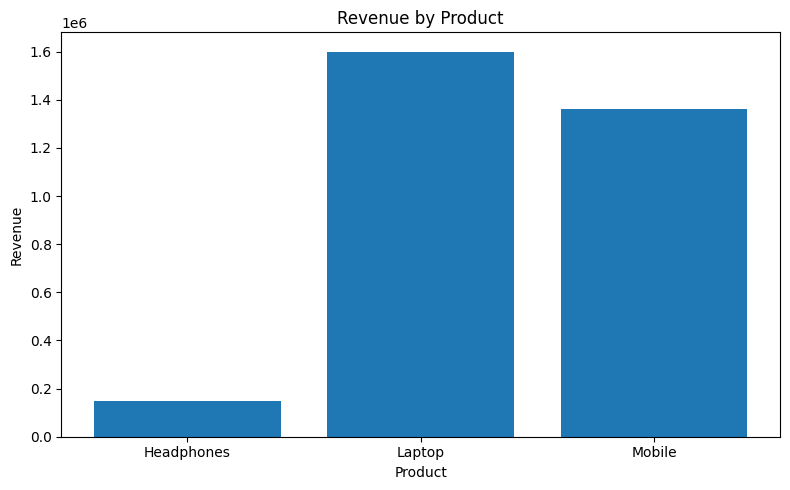

In [37]:
plt.figure(figsize=(8,5))

plt.bar(df["product"], df["revenue"])

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("sales_chart.png")

print("Chart saved as sales_chart.png")

In [38]:
conn.close()

print("Database connection closed.")

Database connection closed.
